In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

### Белый шум

In [5]:
sigma2 = 2
n = 1000
epsilon = np.random.normal(loc = 0, scale = sigma2, size = n)
time = pd.date_range(end = '2026-09-15', periods = n, freq = 'D')
data = pd.DataFrame({'series': epsilon}, index = time)

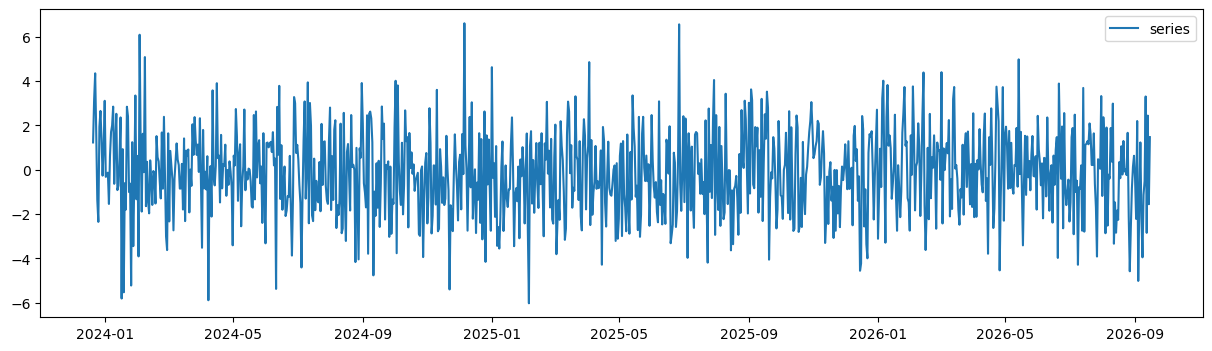

In [6]:
plt.figure(figsize = (15,4))
sns.lineplot(data)
plt.show()

**Автокорреляция**

Автокорреляция - это корреляция временного ряда и его лагов

Лаги порядка h - это наблюдения временного ряда h периодов назад

In [8]:
data['lag1'] = data['series'].shift()
data['lag2'] = data['series'].shift(2)
data['lag3'] = data['series'].shift(3)
data['lag4'] = data['series'].shift(4)
data = data.dropna()
print('Автокорреляция 1 порядка', data['series'].corr(data['lag1']))
print('Автокорреляция 2 порядка', data['series'].corr(data['lag2']))
print('Автокорреляция 3 порядка', data['series'].corr(data['lag3']))
print('Автокорреляция 4 порядка', data['series'].corr(data['lag4']))

Автокорреляция 1 порядка -0.033249197147274326
Автокорреляция 2 порядка -0.003147477886886571
Автокорреляция 3 порядка -0.07099793297451418
Автокорреляция 4 порядка -0.004075224910785358


Существует автокорреляционная функция (ACF), которая показывает значения автокорреляции порядка h в зависимости от h

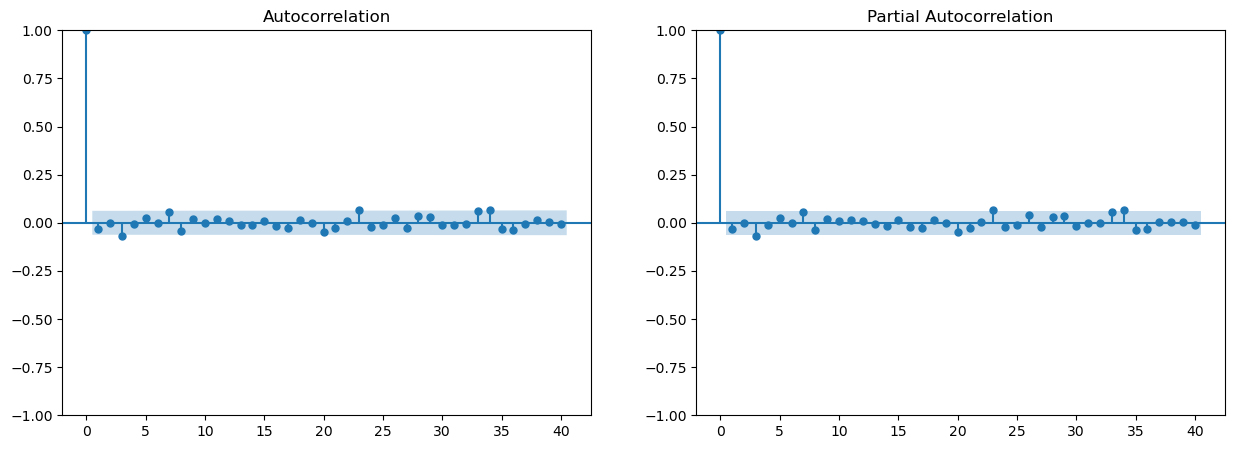

In [10]:
fig,ax = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(data['series'], lags=40, ax=ax[0])
sm.graphics.tsa.plot_pacf(data['series'], lags=40, ax=ax[1])
plt.show()

Если точка (значение автокорреляции) выпадает за границы области (области критических значений), то гипотеза о нулевой автокоррелиции может быть отвергнута => на этом порядке присутствует автокорреляция

### Авторегрессия первого порядка (AR(1))

$Y_t = \delta + \phi \cdot Y_{t-1} + \varepsilon_t$

$\mathbb{E}[Y_{t+1}|Y_t] = \delta + \phi \cdot Y_{t}$

$\mathbb{E}[Y_{t+2}|Y_t] = \delta + \phi \cdot Y_{t+1} = \delta + \phi \cdot [\delta + \phi \cdot Y_{t}] = \delta (1+ \phi) + \phi^2 Y_t$

In [12]:
def simulate_ar_process(delta, phi, sigma2, n = 1000):
    epsilon = np.random.normal(loc = 0, scale = sigma2, size = n)
    time = pd.date_range(end = '2024-10-18', periods = n, freq = 'D')
    series = [delta]
    for t in range(n-1):
        y = delta + phi*series[t] + epsilon[t + 1]
        series.append(y)

    data = pd.DataFrame({'series': series}, index = time)
    
    plt.figure(figsize = (15,4))
    sns.lineplot(data.iloc[20:])
    plt.show()
    
    data['lag1'] = data['series'].shift()
    data['lag2'] = data['series'].shift(2)
    data['lag3'] = data['series'].shift(3)
    data['lag4'] = data['series'].shift(4)
    data = data.dropna()
    print('Автокорреляция 1 порядка', data['series'].corr(data['lag1']))
    print('Автокорреляция 2 порядка', data['series'].corr(data['lag2']))
    print('Автокорреляция 3 порядка', data['series'].corr(data['lag3']))
    print('Автокорреляция 4 порядка', data['series'].corr(data['lag4']))
    
    fig,ax = plt.subplots(1, 2, figsize=(15, 5))
    sm.graphics.tsa.plot_acf(data['series'], lags=20, ax=ax[0])
    sm.graphics.tsa.plot_pacf(data['series'], lags=20, ax=ax[1])
    plt.show()

#### Коэффициент авторeгресии = 0.9

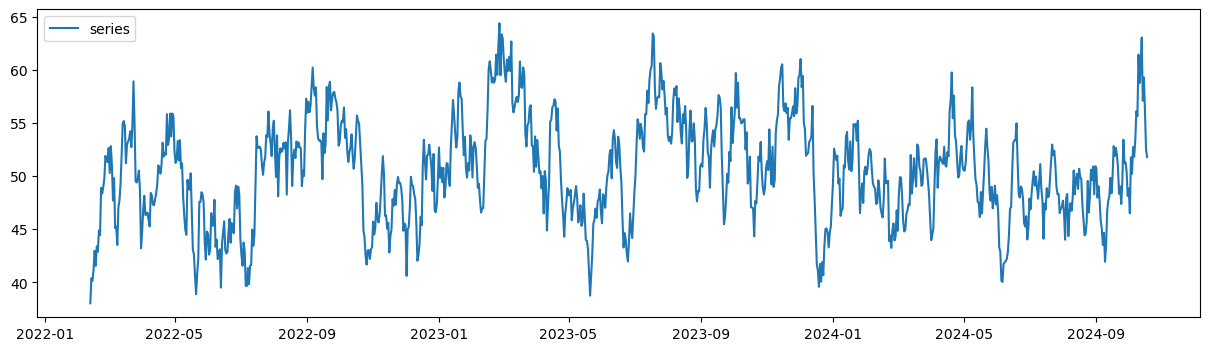

Автокорреляция 1 порядка 0.9232534339352757
Автокорреляция 2 порядка 0.8635436470636743
Автокорреляция 3 порядка 0.8032127410010895
Автокорреляция 4 порядка 0.7423704139717368


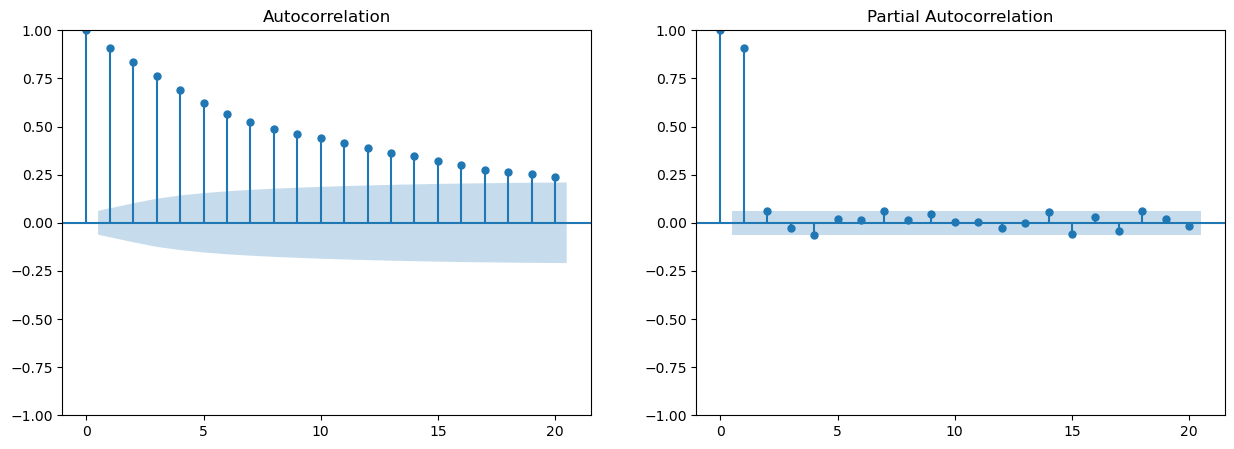

In [13]:
simulate_ar_process(delta = 5, phi = 0.9, sigma2 =2)

#### Коэффициент авторегрессии -0,7

$Y_t = 3 -0.7 \cdot Y_{t-1} + \varepsilon_t$

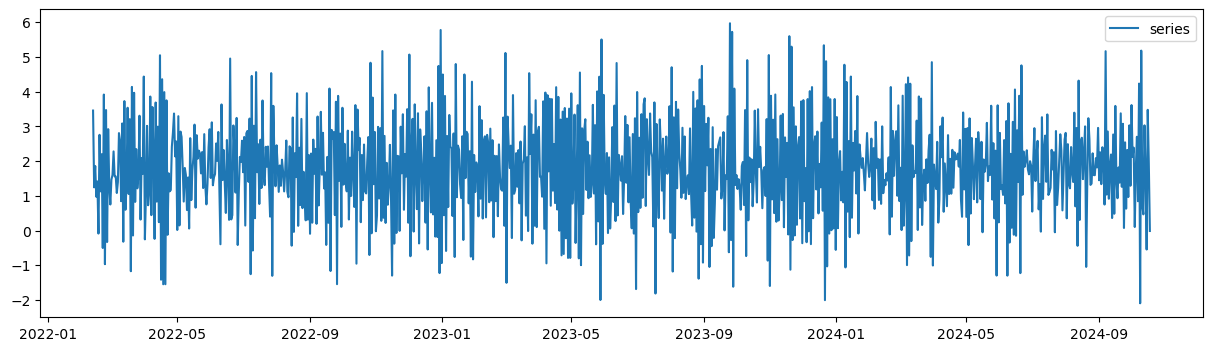

Автокорреляция 1 порядка -0.7244024964559735
Автокорреляция 2 порядка 0.529122629693522
Автокорреляция 3 порядка -0.3815513606637685
Автокорреляция 4 порядка 0.27051400812017296


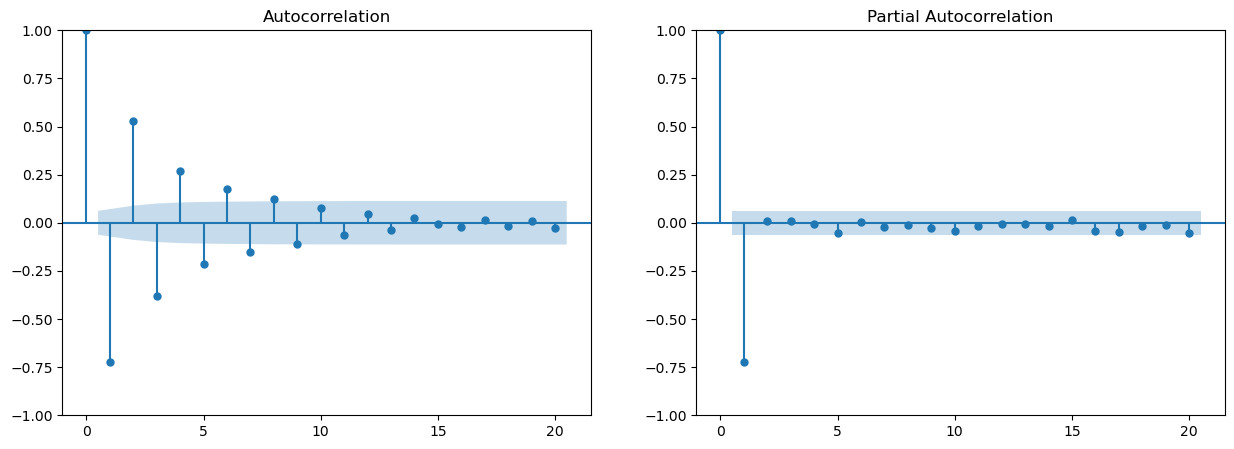

In [14]:
simulate_ar_process(delta = 3, phi = -0.7, sigma2 = 1)

#### Коэффициент авторегрессии 1,01

$Y_t = 3 + 1.01 \cdot Y_{t-1} + \varepsilon_t$

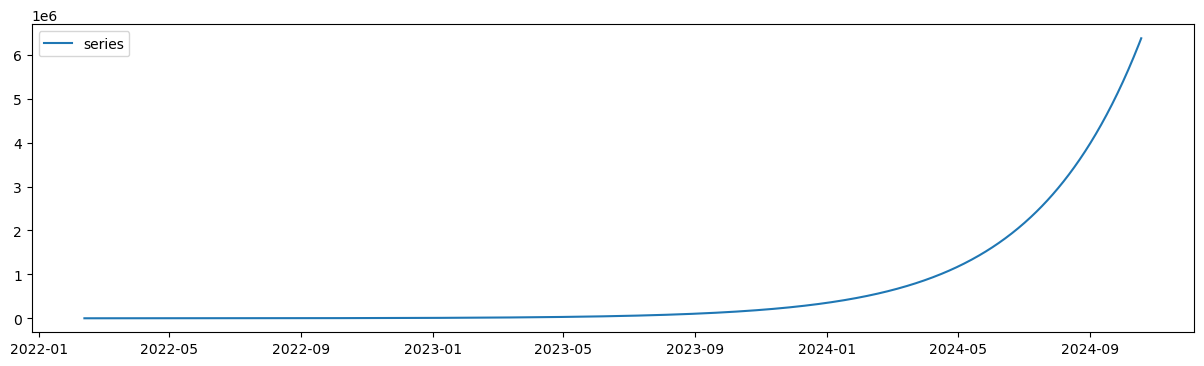

Автокорреляция 1 порядка 0.999999999999691
Автокорреляция 2 порядка 0.9999999999993554
Автокорреляция 3 порядка 0.9999999999989989
Автокорреляция 4 порядка 0.9999999999986048


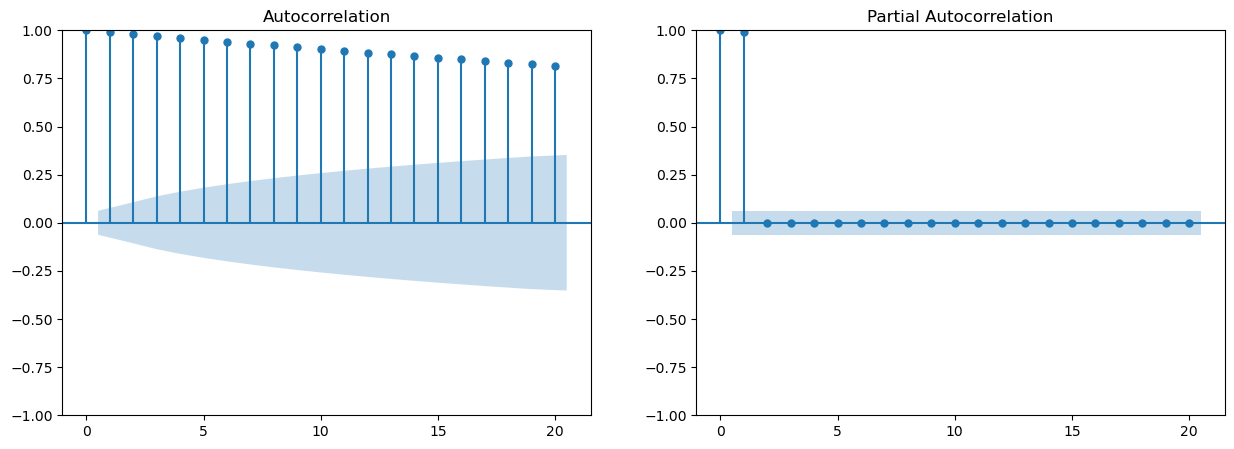

In [16]:
simulate_ar_process(delta = 3, phi = 1.01, sigma2 = 1)

#### Коэффициент авторегрессии равен 1 (случайное блуждание - random walk)

$Y_t =  Y_{t-1} + \varepsilon_t$

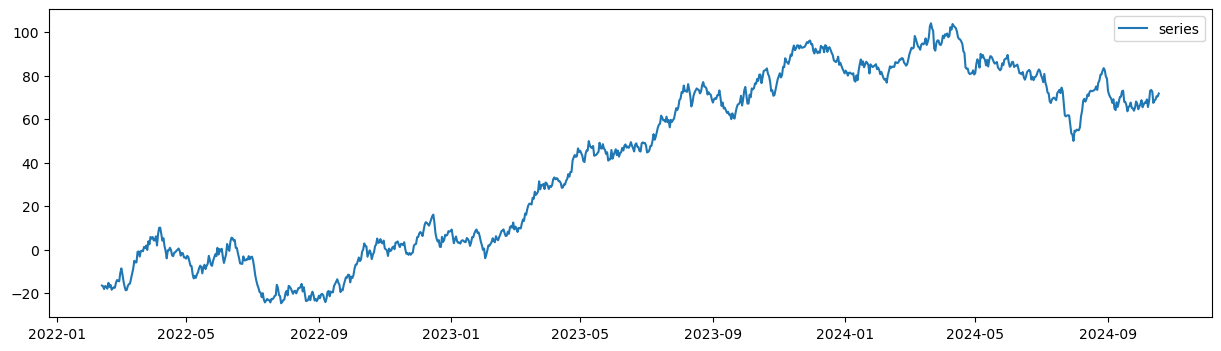

Автокорреляция 1 порядка 0.9988108171219673
Автокорреляция 2 порядка 0.997643215597277
Автокорреляция 3 порядка 0.9963553341025723
Автокорреляция 4 порядка 0.9950701094510628


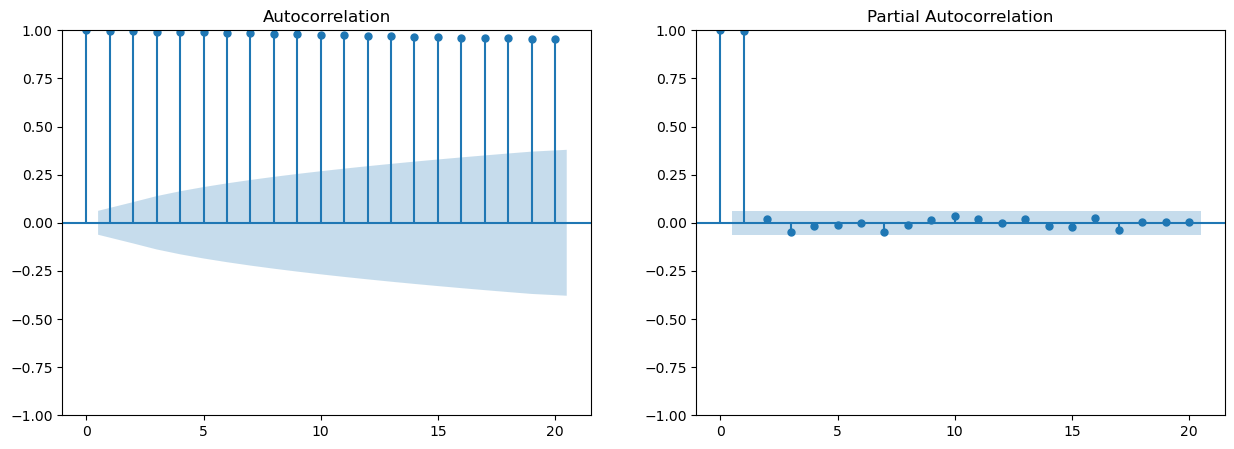

In [17]:
simulate_ar_process(delta = 0, phi = 1, sigma2 = 2)

**Стационарный временной ряд** 

В случае с AR(1) ряд стационарный, если $|\phi|<1$ 

### Модели скользящего среднего

$Y_t = \mu + \theta \cdot \varepsilon_{t-1} + \varepsilon_{t}$

$\mathbb{E}[Y_{t+1} | Y_t] =\mu + \theta \cdot \varepsilon_{t}$

$\mathbb{E}[Y_{t+2} | Y_t] =\mu $

In [13]:
def simulate_ma_process(mu, theta, sigma2, n = 1000):
    epsilon = np.random.normal(loc = 0, scale = sigma2, size = n)
    time = pd.date_range(end = '2024-10-18', periods = n, freq = 'D')
    series = [epsilon[0]]
    for t in range(n-1):
        y = mu + theta*epsilon[t] + epsilon[t + 1]
        series.append(y)

    data = pd.DataFrame({'series': series}, index = time)
    
    plt.figure(figsize = (15,4))
    sns.lineplot(data.iloc[20:])
    plt.show()
    
    data['lag1'] = data['series'].shift()
    data['lag2'] = data['series'].shift(2)
    data['lag3'] = data['series'].shift(3)
    data['lag4'] = data['series'].shift(4)
    data = data.dropna()
    print('Автокорреляция 1 порядка', data['series'].corr(data['lag1']))
    print('Автокорреляция 2 порядка', data['series'].corr(data['lag2']))
    print('Автокорреляция 3 порядка', data['series'].corr(data['lag3']))
    print('Автокорреляция 4 порядка', data['series'].corr(data['lag4']))
    
    fig,ax = plt.subplots(1, 2, figsize=(15, 5))
    sm.graphics.tsa.plot_acf(data['series'], lags=20, ax=ax[0])
    sm.graphics.tsa.plot_pacf(data['series'], lags=20, ax=ax[1])
    plt.show()

#### Тета = 0.9

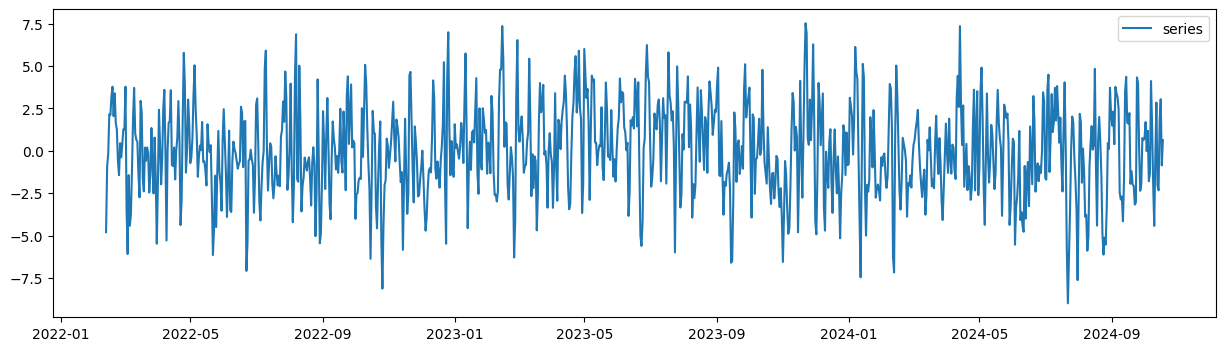

Автокорреляция 1 порядка 0.4990696723325981
Автокорреляция 2 порядка 0.00908582239658873
Автокорреляция 3 порядка -0.0060259375570939685
Автокорреляция 4 порядка 0.004877708823935534


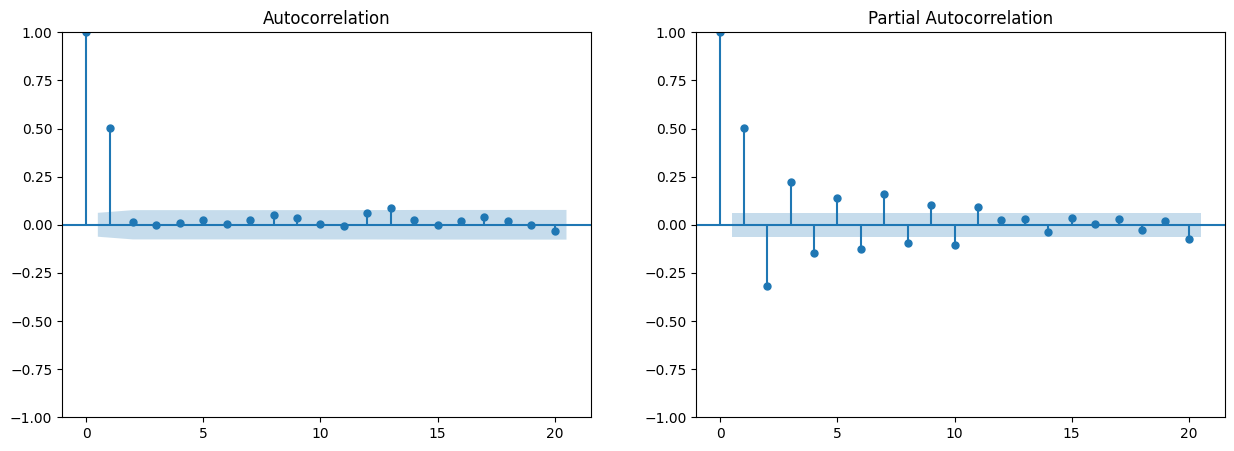

In [14]:
simulate_ma_process(mu = 0, theta = 0.9, sigma2 = 2, n = 1000)

#### Тета = -0.5

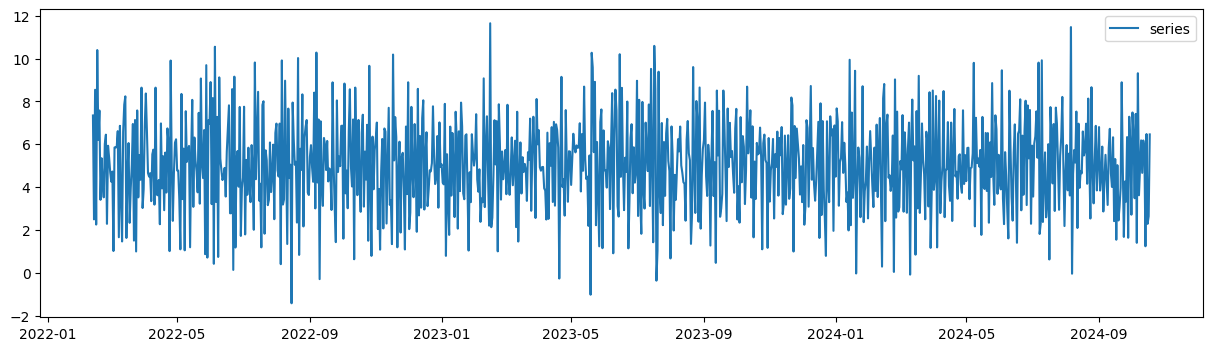

Автокорреляция 1 порядка -0.36786484073832665
Автокорреляция 2 порядка -0.025537087709350918
Автокорреляция 3 порядка 0.013878078589700452
Автокорреляция 4 порядка 0.013552428113890241


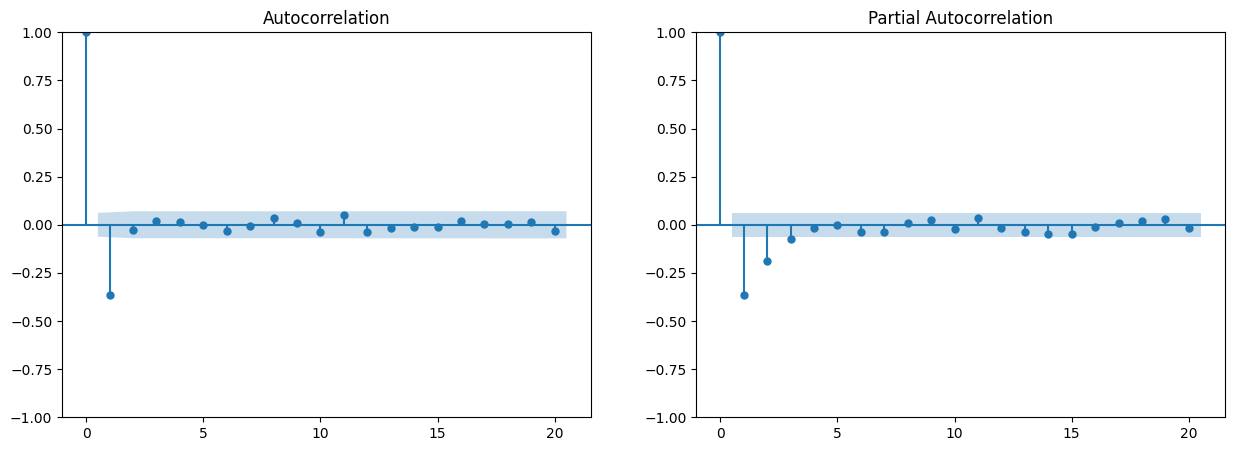

In [15]:
simulate_ma_process(mu = 5, theta = -0.5, sigma2 = 2, n = 1000)

#### Тета  = 1,1

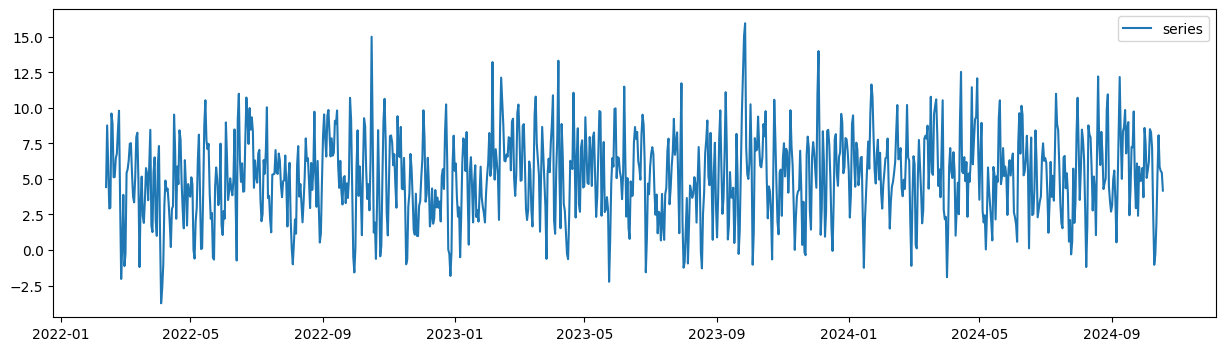

Автокорреляция 1 порядка 0.49824399410342735
Автокорреляция 2 порядка 0.007451382846384537
Автокорреляция 3 порядка -0.012458053035660591
Автокорреляция 4 порядка -0.008337317683814818


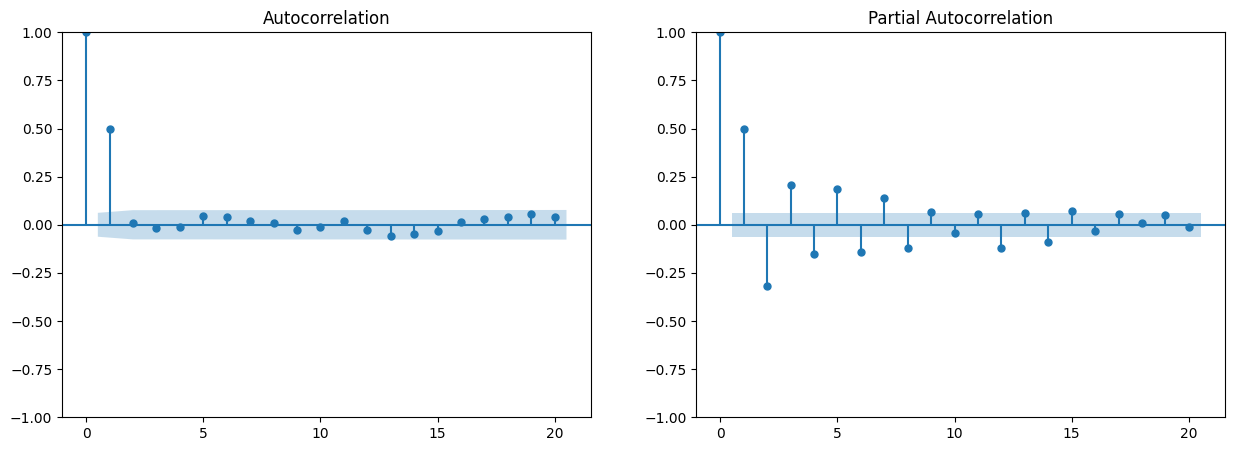

In [16]:
simulate_ma_process(mu = 5, theta = 1.1, sigma2 = 2, n = 1000)

1) Если процесс стационарный, то наиболее простыми моделями для его описания являются AR или MA модели

2) Если график автокорреляции показывает продолжительное убывающее значение автокорреляции на множестве лагов, то, скорее всего, подходящей моделью будет является AR

3) Если график автокорреляции показывает значимую корреляция только одного лага, то, скорее всего, подходящей моделью будет являться MA 

### Стационарность и нестационарность

Стационарный временной ряд не меняет со временем своих основных характеристик: среднее значение и дисперсия

Две ситуации нестационарности:

1) Наличие тренда (детерминированного либо стохастического)

2) Наличие разрывов

### Детерминированный линейный тренд

In [18]:
def simulate_linear_trend_process(b0, b1, delta, phi, sigma2, n = 1000):
    epsilon = np.random.normal(loc = 0, scale = sigma2, size = n)
    time = pd.date_range(end = '2026-09-15', periods = n, freq = 'D')
    series = [delta]
    for t in range(n-1):
        trend = b0 + b1*t
        y = trend  +  delta + phi*series[t] + epsilon[t + 1] 
        series.append(y)

    data = pd.DataFrame({'series': series}, index = time)
    
    plt.figure(figsize = (15,4))
    sns.lineplot(data.iloc[20:])
    plt.show()
    
    data['lag1'] = data['series'].shift()
    data['lag2'] = data['series'].shift(2)
    data['lag3'] = data['series'].shift(3)
    data['lag4'] = data['series'].shift(4)
    data = data.dropna()
    print('Автокорреляция 1 порядка', data['series'].corr(data['lag1']))
    print('Автокорреляция 2 порядка', data['series'].corr(data['lag2']))
    print('Автокорреляция 3 порядка', data['series'].corr(data['lag3']))
    print('Автокорреляция 4 порядка', data['series'].corr(data['lag4']))
    
    sm.graphics.tsa.plot_acf(data['series'], lags=20)
    plt.show()

$ Y_t = 1 + 2 \cdot t + u_t$

$ u_t = 10 + 0.9 \cdot u_{t-1} + \varepsilon_t$

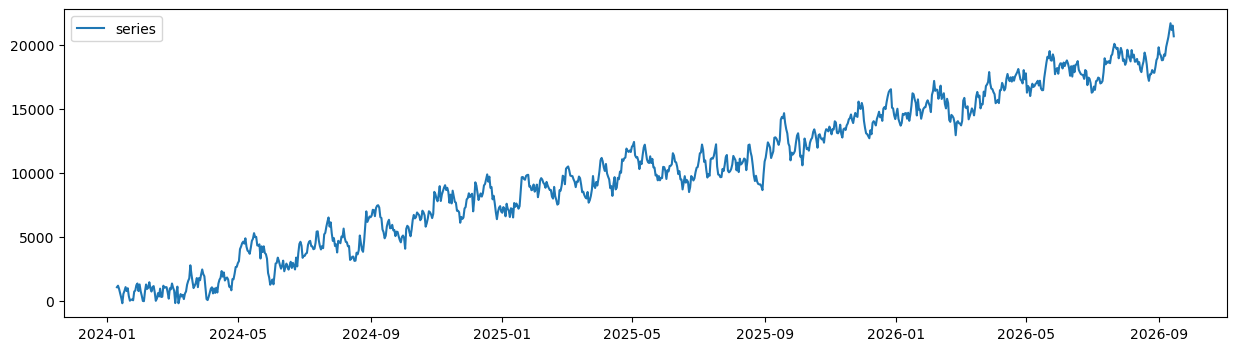

Автокорреляция 1 порядка 0.9959103420221673
Автокорреляция 2 порядка 0.992318616328879
Автокорреляция 3 порядка 0.9888577187800469
Автокорреляция 4 порядка 0.9859661954183517


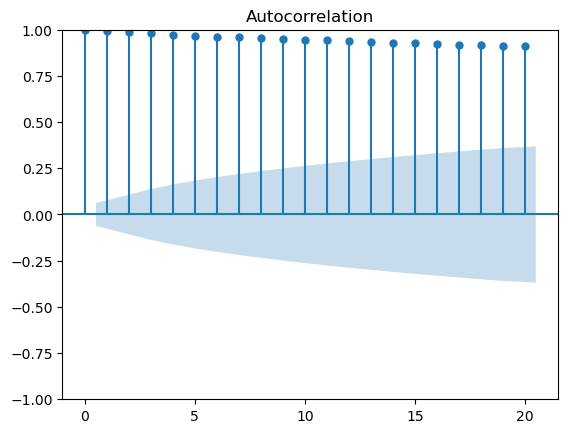

In [19]:
simulate_linear_trend_process(b0 = 1, b1 = 2, delta = 10, phi = 0.9 , sigma2 = 500, n = 1000)

### Детерминированный квадратичный тренд

In [20]:
def simulate_quadratic_trend_process(b0, b1, b2, delta, phi, sigma2, n = 1000):
    epsilon = np.random.normal(loc = 0, scale = sigma2, size = n)
    time = pd.date_range(end = '2024-10-18', periods = n, freq = 'D')
    series = [delta]
    for t in range(n-1):
        trend = b0 + b1*t + b2*(t**2)
        y = trend  +  delta + phi*series[t] + epsilon[t + 1] 
        series.append(y)

    data = pd.DataFrame({'series': series}, index = time)
    
    plt.figure(figsize = (15,4))
    sns.lineplot(data.iloc[20:])
    plt.show()
    
    data['lag1'] = data['series'].shift()
    data['lag2'] = data['series'].shift(2)
    data['lag3'] = data['series'].shift(3)
    data['lag4'] = data['series'].shift(4)
    data = data.dropna()
    print('Автокорреляция 1 порядка', data['series'].corr(data['lag1']))
    print('Автокорреляция 2 порядка', data['series'].corr(data['lag2']))
    print('Автокорреляция 3 порядка', data['series'].corr(data['lag3']))
    print('Автокорреляция 4 порядка', data['series'].corr(data['lag4']))
    
    sm.graphics.tsa.plot_acf(data['series'], lags=20)
    plt.show()

$ Y_t = 1 + 4 \cdot t  - 0.002 \cdot t^2 + u_t$

$ u_t = 10 + 0.9 \cdot u_{t-1} + \varepsilon_t$

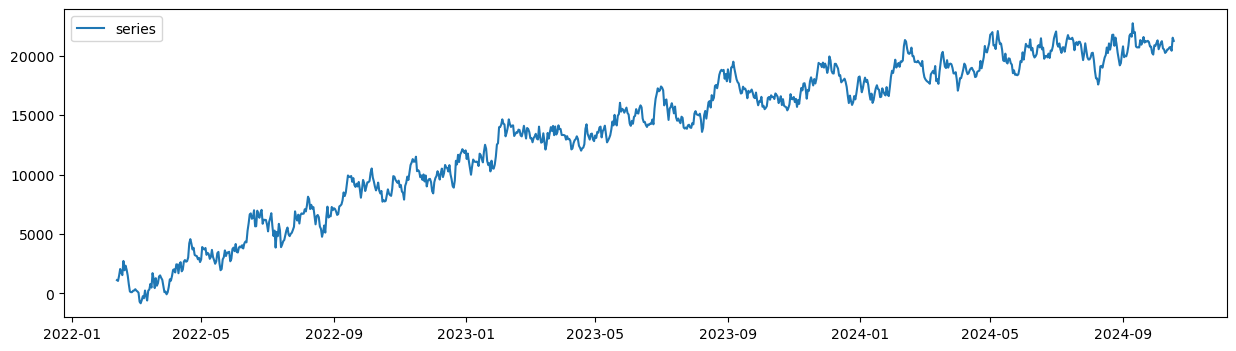

Автокорреляция 1 порядка 0.9968804665944475
Автокорреляция 2 порядка 0.9942543337487251
Автокорреляция 3 порядка 0.9921165629603924
Автокорреляция 4 порядка 0.9901539004404928


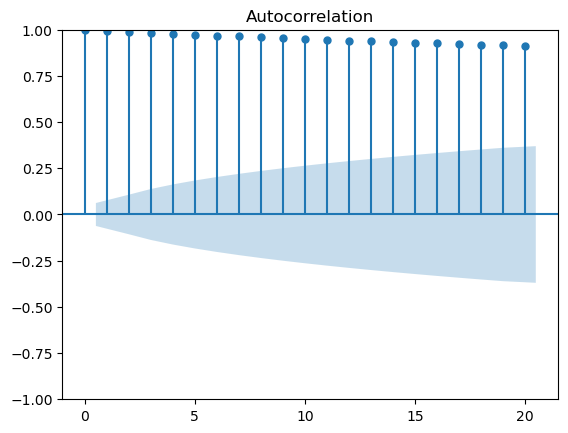

In [21]:
simulate_quadratic_trend_process(b0 = 1, b1 = 4, b2 = -0.002, delta = 10, phi = 0.9, sigma2 = 500, n = 1000)